## Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library liabrary built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

# Loading Data

In [2]:
df = pd.read_csv("/Users/williamdang/Documents/Education/Data/education_clean.csv")

In [3]:
df.head(10)

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804.0,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709.0,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709.0,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958.0,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934.0,Regular School,High,No
5,100019000050,0.080120,0.673492,0.483333,50649.0,17.034188,0.425118,2016-2017,DE,19904.0,Regular School,High,No
6,100020000238,0.075058,0.750751,0.515685,12825.0,18.387057,0.338928,2016-2017,DE,19711.0,Regular School,High,No
7,100020000239,0.075424,0.616605,0.595445,59861.0,15.544567,0.372116,2016-2017,DE,19702.0,Regular School,High,No
8,100020000240,0.114201,0.594220,0.672059,62078.0,14.980464,0.352801,2016-2017,DE,19713.0,Regular School,High,No
9,100023000209,0.039931,0.540456,0.840810,61031.0,15.105006,0.358939,2016-2017,DE,19720.0,Regular School,High,No


## Exploratory data analysis

# Examine distributions and relationships

Plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables

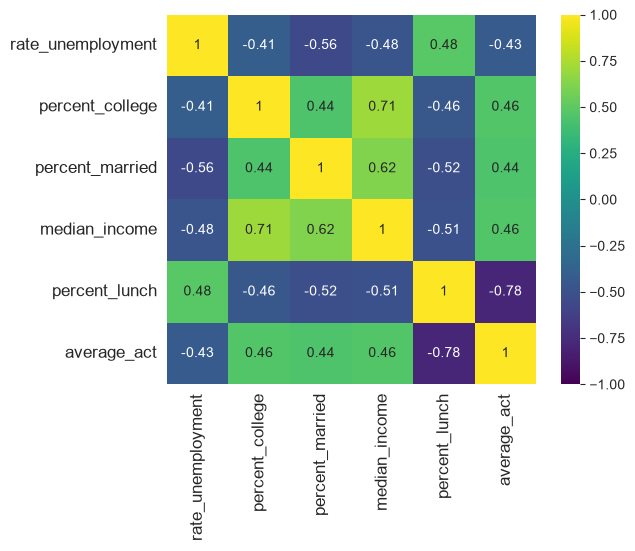

In [6]:
predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter'
]
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors +["average_act"]].corr()

sns.heatmap(
    corr_matrix, vmax= 1, vmin = -1, square = True, annot = True, cmap = "viridis"
)

plt.tick_params(labelsize=12)

plt.show()
    

Make pair plots to explore relationships between the variables

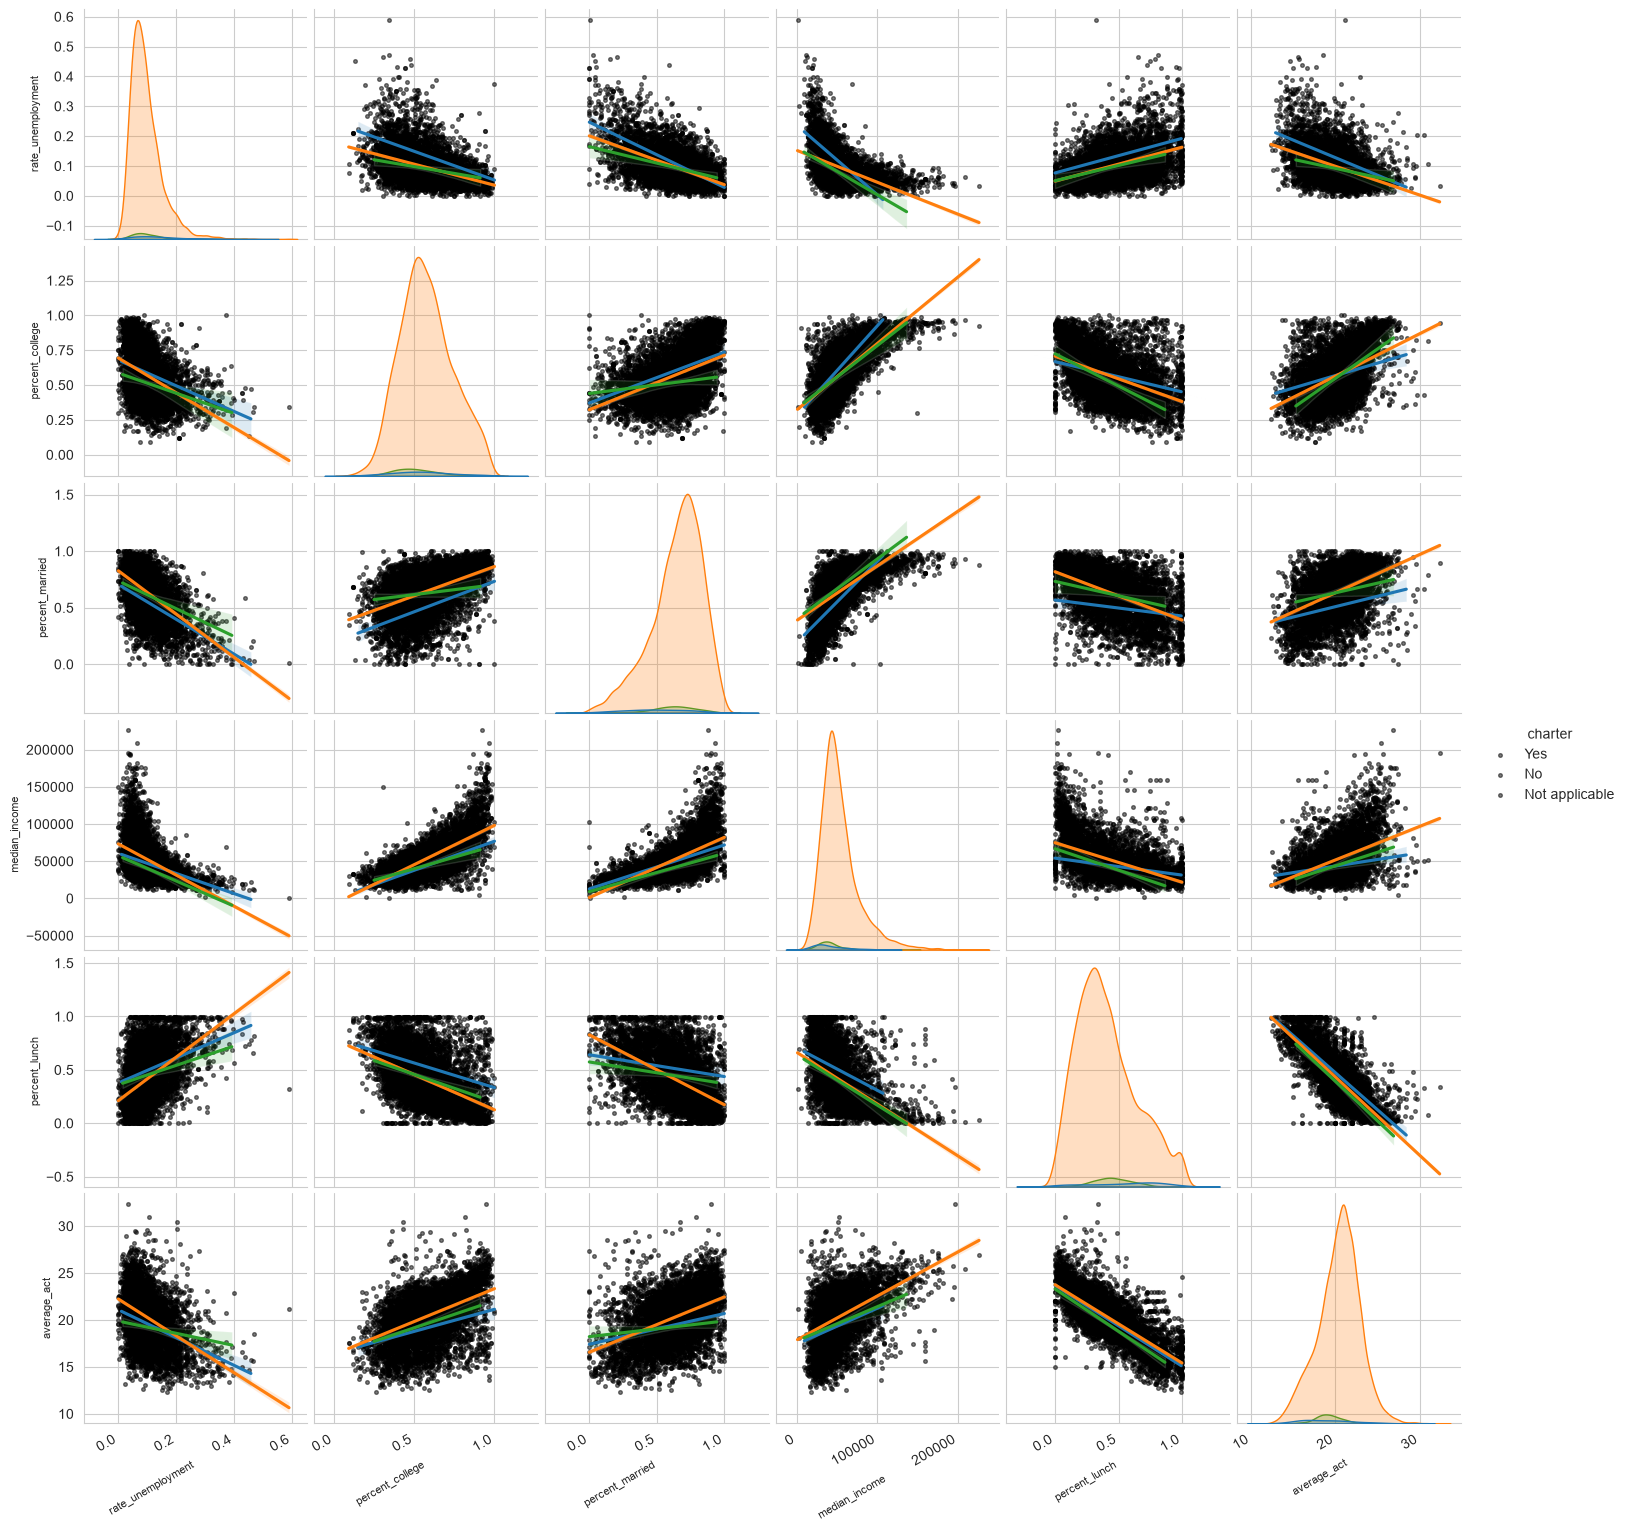

In [8]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors +['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={
        "scatter_kws":{"alpha":0.5,"color":"k","s":7},
    }
)

for ax in fig.axes.flat:
    if ax.get_xlabel()== 'CT Median Household Income':
        ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0)) # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') #x=axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

   # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

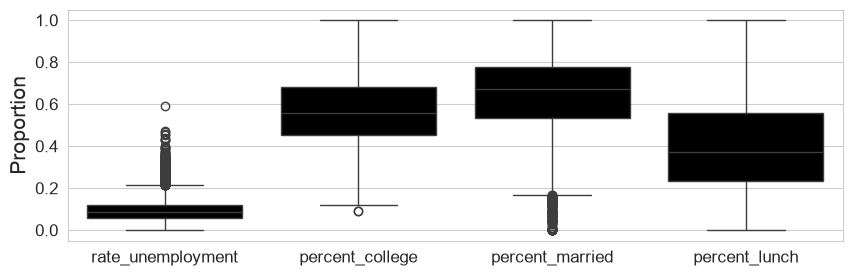

In [11]:
plt.figure(figsize=(10,3))
fractions = list(numerical_predictors)
fractions.remove('median_income')



sns.boxplot(data=df[fractions], color='k')
plt.ylabel('Proportion', fontsize=15)
plt.tick_params(labelsize=12)
plt.show()

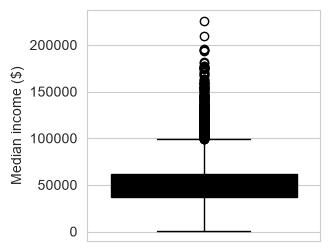

In [12]:
plt.figure(figsize=(3,3))
sns.boxplot(data=df, y='median_income', color='k')
plt.ylabel('Median income ($)')
plt.show()